### Metric Testing

This notebook is for testing additional metrics to compare the Molmo and Gemma models.

The current metrics being considered are CIDEr and SPICE

CIDEr has heavy penalties towards answers longer than the caption.
CIDEr compares n-gram sequences among the generated and gt captions. 
This makes it very good at seeing overall themes or trends in gen captions

SPICE turns each caption into a graph / tuple of attributes and heavily penalizes captions that do not align. 
Initialy testing showed very low scores, and it may not be a great metric for this project since we are focused on general accuracy and overall performance of the model. Much less on sentence strucutre, as long as generations are grammatically reasonable


**Other options**

1. CLIPScore
Uses a clip model to compare the similarity of the embeddings from the image itself and the generated captions. DOES NOT consider other captions for gt. Directly compares the image embeddings to the text embeddings. Could be useful for initial testing, not sure about performance in ablation since the image is changing

For ablation, perform inference on altered images, but uring CLIP scoring compare unaltered ground truth images with captions generated from altered data

2. 

In [1]:
#Imports
import sys
import os
import torch
import clip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
import json
import nltk
from nltk.translate.meteor_score import meteor_score

# Download WordNet data for METEOR synonyms
nltk.download('wordnet')
nltk.download('omw-1.4')

# Setup style
sns.set_theme(style="whitegrid")

[nltk_data] Downloading package wordnet to
[nltk_data]     /home/devin_work/nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/devin_work/nltk_data...


In [3]:
#Inputs
# Paths relative to notebooks/testing-notebooks/
IMAGE_DIR = "../../data/coco-dataset/val2017"
ANNOTATIONS_PATH = "../../data/coco-dataset/annotations/captions_val2017.json"
RESULTS_CSV = "../../results/metrics-results/gemma_COCO_val_20260424_102829.csv"

# Load existing metrics
df = pd.read_csv(RESULTS_CSV)

# Load COCO Ground Truths for METEOR
with open(ANNOTATIONS_PATH, 'r') as f:
    coco_data = json.load(f)

# Map Image_ID (int) to list of reference captions
id_to_gts = {}
for ann in coco_data['annotations']:
    id_to_gts.setdefault(ann['image_id'], []).append(ann['caption'])

print(f"Loaded {len(df)} results and {len(id_to_gts)} reference sets.")

# Test on a subset of 100 images to evaluate performance
sample_df = df.sample(100).copy()

Loaded 5000 results and 5000 reference sets.


In [4]:
#CLIPScore Testing

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

def get_clean_id(image_id):
    """Extracts the integer ID from a filename or string."""
    if isinstance(image_id, str):
        # Removes .jpg, .png, etc., and takes just the numeric part
        return int(image_id.split('.')[0])
    return int(image_id)

def calculate_clip_score(row):
    img_id_raw = row['Image_ID']
    
    # If it's already a filename, use it. Otherwise, format it as a 12-digit JPG
    if isinstance(img_id_raw, str) and img_id_raw.endswith('.jpg'):
        img_filename = img_id_raw
    else:
        img_filename = str(img_id_raw).zfill(12) + ".jpg"
        
    img_path = os.path.join(IMAGE_DIR, img_filename)
    
    try:
        image = preprocess(Image.open(img_path)).unsqueeze(0).to(device)
        text = clip.tokenize([row['Generated_Caption']], truncate=True).to(device)
        
        with torch.no_grad():
            image_features = model.encode_image(image)
            text_features = model.encode_text(text)
            
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features /= text_features.norm(dim=-1, keepdim=True)
            return (image_features @ text_features.T).item()
    except Exception as e:
        return None

# Run on the sample
print("Calculating CLIPScores...")
sample_df['CLIPScore'] = sample_df.apply(calculate_clip_score, axis=1)

print(f"Average CLIPScore: {sample_df['CLIPScore'].mean():.4f}")

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 80.0MiB/s]


Calculating CLIPScores...
Average CLIPScore: 0.3274


Calculating METEOR scores...


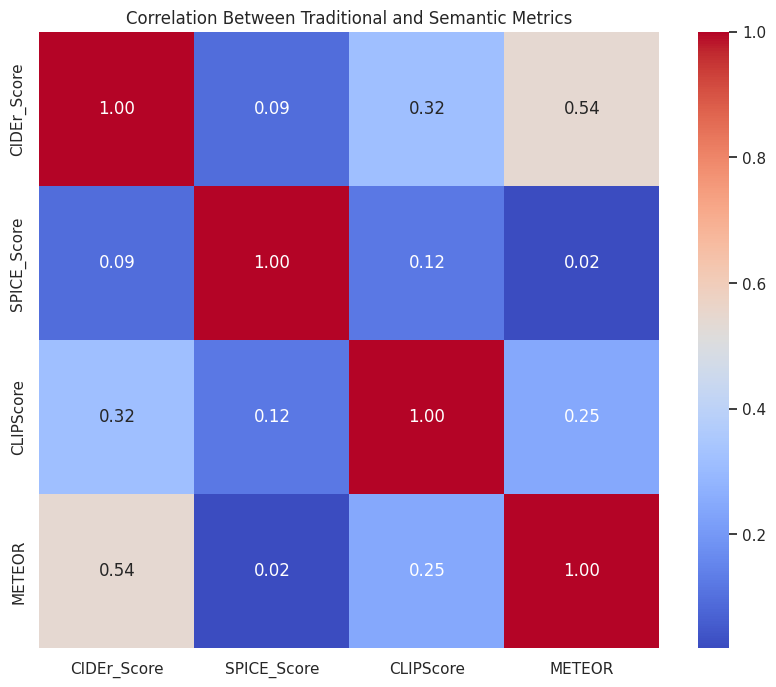

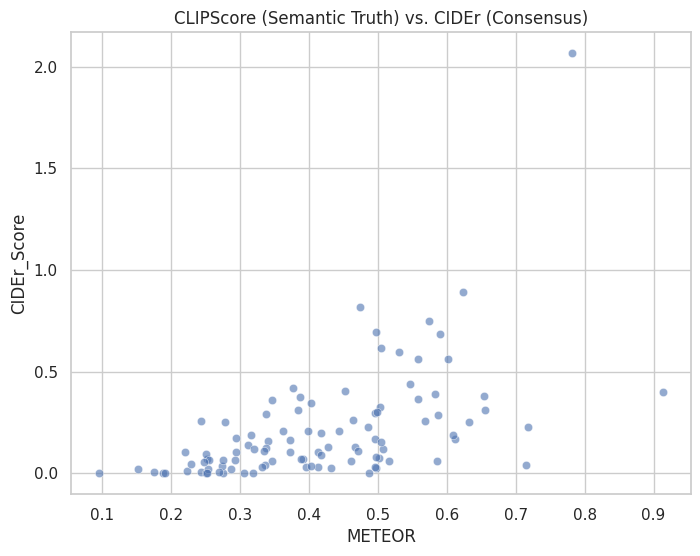

In [8]:
#Meteor Testing 

def calculate_meteor(row):
    # Clean the ID to match the integer keys in id_to_gts
    img_id = get_clean_id(row['Image_ID'])
    
    references = id_to_gts.get(img_id, [])
    if not references:
        return 0.0
    
    # METEOR expects tokens: list of reference-token-lists and a hypothesis-token-list
    ref_list = [ref.split() for ref in references]
    hyp = row['Generated_Caption'].split()
    return meteor_score(ref_list, hyp)

print("Calculating METEOR scores...")
sample_df['METEOR'] = sample_df.apply(calculate_meteor, axis=1)

# Visualizing Correlations
plt.figure(figsize=(10, 8))
corr = sample_df[['CIDEr_Score', 'SPICE_Score', 'CLIPScore', 'METEOR']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Traditional and Semantic Metrics")
plt.show()

# Scatter Plot: CLIPScore vs CIDEr
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x='METEOR', y='CIDEr_Score', alpha=0.6)
plt.title("CLIPScore (Semantic Truth) vs. CIDEr (Consensus)")
plt.show()